Linear regression _ Social Anxiety

In [340]:
import pandas as pd
import numpy as np #importing numpy to use with IQR - outlier removal later

In [341]:
df = pd.read_csv('family_anxiety_14_dataset.csv') #using pandas, import our dataset

In [342]:
df.head()

,Age,Gender,Occupation,Sleep Hours,Physical Activity (hrs/week),Caffeine Intake (mg/day),Alcohol Consumption (drinks/week),Smoking,Family History of Anxiety,Stress Level (1-10),Heart Rate (bpm),Breathing Rate (breaths/min),Sweating Level (1-5),Dizziness,Medication,Therapy Sessions (per month),Recent Major Life Event,Diet Quality (1-10),Anxiety Level (1-10)
0,58,Male,Nurse,6.2,1.3,192,16,No,Yes,1,117,21,1,No,Yes,9,No,1,3.0
1,39,Female,Engineer,8.6,3.8,367,15,No,No,10,113,14,3,Yes,Yes,6,Yes,3,4.0
2,42,Female,Doctor,6.6,0.5,132,1,No,No,10,79,20,1,Yes,No,1,No,6,6.0
3,43,Female,Athlete,7.0,1.6,361,15,No,No,4,69,25,2,Yes,No,5,Yes,10,2.0
4,55,Other,Athlete,7.6,2.8,531,0,No,No,3,65,12,4,No,No,6,Yes,4,4.0


In [343]:
df.isnull().sum() # checking for mising values

Age                                  0
Gender                               0
Occupation                           0
Sleep Hours                          0
Physical Activity (hrs/week)         0
Caffeine Intake (mg/day)             0
Alcohol Consumption (drinks/week)    0
Smoking                              0
Family History of Anxiety            0
Stress Level (1-10)                  0
Heart Rate (bpm)                     0
Breathing Rate (breaths/min)         0
Sweating Level (1-5)                 0
Dizziness                            0
Medication                           0
Therapy Sessions (per month)         0
Recent Major Life Event              0
Diet Quality (1-10)                  0
Anxiety Level (1-10)                 0
dtype: int64

In [344]:
df.duplicated().sum() #checking for duplicate values

0

In [345]:
df.select_dtypes(include='object').head() #check for object data type columns in our dataset -Linear rgression does now accept categorical data types

,Gender,Occupation,Smoking,Family History of Anxiety,Dizziness,Medication,Recent Major Life Event
0,Male,Nurse,No,Yes,No,Yes,No
1,Female,Engineer,No,No,Yes,Yes,Yes
2,Female,Doctor,No,No,Yes,No,No
3,Female,Athlete,No,No,Yes,No,Yes
4,Other,Athlete,No,No,No,No,Yes


In [346]:
#check for object data type columns in our dataset -Linear rgression does now accept categorical data types and object data types
#let's print the first entries of the object and categorical data types
df.select_dtypes(include=['object','category']).head()

,Gender,Occupation,Smoking,Family History of Anxiety,Dizziness,Medication,Recent Major Life Event
0,Male,Nurse,No,Yes,No,Yes,No
1,Female,Engineer,No,No,Yes,Yes,Yes
2,Female,Doctor,No,No,Yes,No,No
3,Female,Athlete,No,No,Yes,No,Yes
4,Other,Athlete,No,No,No,No,Yes


In [347]:
df.info() #much easier to read the above code then using .info() method

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11000 entries, 0 to 10999
Data columns (total 19 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Age                                11000 non-null  int64  
 1   Gender                             11000 non-null  object 
 2   Occupation                         11000 non-null  object 
 3   Sleep Hours                        11000 non-null  float64
 4   Physical Activity (hrs/week)       11000 non-null  float64
 5   Caffeine Intake (mg/day)           11000 non-null  int64  
 6   Alcohol Consumption (drinks/week)  11000 non-null  int64  
 7   Smoking                            11000 non-null  object 
 8   Family History of Anxiety          11000 non-null  object 
 9   Stress Level (1-10)                11000 non-null  int64  
 10  Heart Rate (bpm)                   11000 non-null  int64  
 11  Breathing Rate (breaths/min)       11000 non-null  int

In [348]:
#Let's start configuring these object data types in Numerical values

#Dealing with Gender colunm

#As gender has 3 entries 'Male,'Female and 'Other' we need to deal with this
df['Gender'].value_counts()

Other     3706
Male      3666
Female    3628
Name: Gender, dtype: int64

In [349]:
#Label encoding is not an option when pre-processing a dataset for Linear Rgression
#Our Linear Regression model might interpret these numbers as Ordinal, and our model will believe that 'Other' : 3 is more import tan 'Male' : 1 and 'Female'0'

#I do not want to remove all other entries as it will remove one third of our dataset
#We will use One-Hot Encoding - creating three new columns for our dataset separting the Gender entries

df_ds = pd.get_dummies(df,columns=['Gender'])

In [350]:
#- I will be checking be multiconllinearity later in the dataset - our other column might be deleted later
df_ds.head()

,Age,Occupation,Sleep Hours,Physical Activity (hrs/week),Caffeine Intake (mg/day),Alcohol Consumption (drinks/week),Smoking,Family History of Anxiety,Stress Level (1-10),Heart Rate (bpm),...,Sweating Level (1-5),Dizziness,Medication,Therapy Sessions (per month),Recent Major Life Event,Diet Quality (1-10),Anxiety Level (1-10),Gender_Female,Gender_Male,Gender_Other
0,58,Nurse,6.2,1.3,192,16,No,Yes,1,117,...,1,No,Yes,9,No,1,3.0,0,1,0
1,39,Engineer,8.6,3.8,367,15,No,No,10,113,...,3,Yes,Yes,6,Yes,3,4.0,1,0,0
2,42,Doctor,6.6,0.5,132,1,No,No,10,79,...,1,Yes,No,1,No,6,6.0,1,0,0
3,43,Athlete,7.0,1.6,361,15,No,No,4,69,...,2,Yes,No,5,Yes,10,2.0,1,0,0
4,55,Athlete,7.6,2.8,531,0,No,No,3,65,...,4,No,No,6,Yes,4,4.0,0,0,1


In [351]:

df_ds.select_dtypes(include=['object','category']).head() #we no longer have a Gender column in our dataset

,Occupation,Smoking,Family History of Anxiety,Dizziness,Medication,Recent Major Life Event
0,Nurse,No,Yes,No,Yes,No
1,Engineer,No,No,Yes,Yes,Yes
2,Doctor,No,No,Yes,No,No
3,Athlete,No,No,Yes,No,Yes
4,Athlete,No,No,No,No,Yes


In [352]:
#Moving on to Occupation - we will use the same idea with our one-hot encoding - pd.get_dummies

df_ds = pd.get_dummies(df_ds,columns=['Occupation'],drop_first=True) #creating new columns for our inividual professions

In [353]:
df_ds.head()

,Age,Sleep Hours,Physical Activity (hrs/week),Caffeine Intake (mg/day),Alcohol Consumption (drinks/week),Smoking,Family History of Anxiety,Stress Level (1-10),Heart Rate (bpm),Breathing Rate (breaths/min),...,Occupation_Doctor,Occupation_Engineer,Occupation_Freelancer,Occupation_Lawyer,Occupation_Musician,Occupation_Nurse,Occupation_Other,Occupation_Scientist,Occupation_Student,Occupation_Teacher
0,58,6.2,1.3,192,16,No,Yes,1,117,21,...,0,0,0,0,0,1,0,0,0,0
1,39,8.6,3.8,367,15,No,No,10,113,14,...,0,1,0,0,0,0,0,0,0,0
2,42,6.6,0.5,132,1,No,No,10,79,20,...,1,0,0,0,0,0,0,0,0,0
3,43,7.0,1.6,361,15,No,No,4,69,25,...,0,0,0,0,0,0,0,0,0,0
4,55,7.6,2.8,531,0,No,No,3,65,12,...,0,0,0,0,0,0,0,0,0,0


In [354]:
#Dealing with our Smoking Columns - here I will map 0 to non-smoking and 1 to smoking
smoke_map = {'No':0,'Yes':1}

df_ds['Smoking'] = df_ds['Smoking'].map(smoke_map)

In [355]:
df_ds.head()

,Age,Sleep Hours,Physical Activity (hrs/week),Caffeine Intake (mg/day),Alcohol Consumption (drinks/week),Smoking,Family History of Anxiety,Stress Level (1-10),Heart Rate (bpm),Breathing Rate (breaths/min),...,Occupation_Doctor,Occupation_Engineer,Occupation_Freelancer,Occupation_Lawyer,Occupation_Musician,Occupation_Nurse,Occupation_Other,Occupation_Scientist,Occupation_Student,Occupation_Teacher
0,58,6.2,1.3,192,16,0,Yes,1,117,21,...,0,0,0,0,0,1,0,0,0,0
1,39,8.6,3.8,367,15,0,No,10,113,14,...,0,1,0,0,0,0,0,0,0,0
2,42,6.6,0.5,132,1,0,No,10,79,20,...,1,0,0,0,0,0,0,0,0,0
3,43,7.0,1.6,361,15,0,No,4,69,25,...,0,0,0,0,0,0,0,0,0,0
4,55,7.6,2.8,531,0,0,No,3,65,12,...,0,0,0,0,0,0,0,0,0,0


In [356]:
#checking again for object and categorical data types
df_ds.select_dtypes(include=['object','category']).head()

,Family History of Anxiety,Dizziness,Medication,Recent Major Life Event
0,Yes,No,Yes,No
1,No,Yes,Yes,Yes
2,No,Yes,No,No
3,No,Yes,No,Yes
4,No,No,No,Yes


In [357]:
#checking value counts for the last 4 columns

print(df_ds['Family History of Anxiety'].value_counts())
print()
print(df_ds['Dizziness'].value_counts())
print()
print(df_ds['Medication'].value_counts())
print()
print(df_ds['Recent Major Life Event'].value_counts())

No     9531
Yes    1469
Name: Family History of Anxiety, dtype: int64

Yes    5697
No     5303
Name: Dizziness, dtype: int64

Yes    5597
No     5403
Name: Medication, dtype: int64

Yes    5751
No     5249
Name: Recent Major Life Event, dtype: int64


In [358]:
#as all the value counts for the last 4 object data type columns are binary I will assign No: 0 and Yes: 1

binary_map = {'No':0, 'Yes':1}

df_ds['Family History of Anxiety'] = df_ds['Family History of Anxiety'].map(binary_map)
df_ds['Dizziness'] = df_ds['Dizziness'].map(binary_map)
df_ds['Medication'] = df_ds['Medication'].map(binary_map)
df_ds['Recent Major Life Event'] = df_ds['Recent Major Life Event'].map(binary_map)

In [359]:
df_ds.head()

,Age,Sleep Hours,Physical Activity (hrs/week),Caffeine Intake (mg/day),Alcohol Consumption (drinks/week),Smoking,Family History of Anxiety,Stress Level (1-10),Heart Rate (bpm),Breathing Rate (breaths/min),...,Occupation_Doctor,Occupation_Engineer,Occupation_Freelancer,Occupation_Lawyer,Occupation_Musician,Occupation_Nurse,Occupation_Other,Occupation_Scientist,Occupation_Student,Occupation_Teacher
0,58,6.2,1.3,192,16,0,1,1,117,21,...,0,0,0,0,0,1,0,0,0,0
1,39,8.6,3.8,367,15,0,0,10,113,14,...,0,1,0,0,0,0,0,0,0,0
2,42,6.6,0.5,132,1,0,0,10,79,20,...,1,0,0,0,0,0,0,0,0,0
3,43,7.0,1.6,361,15,0,0,4,69,25,...,0,0,0,0,0,0,0,0,0,0
4,55,7.6,2.8,531,0,0,0,3,65,12,...,0,0,0,0,0,0,0,0,0,0


In [360]:
#Checking the value counts after mapping - all data types are int64 dtype

print(df_ds['Family History of Anxiety'].value_counts())
print()
print(df_ds['Dizziness'].value_counts())
print()
print(df_ds['Medication'].value_counts())
print()
print(df_ds['Recent Major Life Event'].value_counts())

0    9531
1    1469
Name: Family History of Anxiety, dtype: int64

1    5697
0    5303
Name: Dizziness, dtype: int64

1    5597
0    5403
Name: Medication, dtype: int64

1    5751
0    5249
Name: Recent Major Life Event, dtype: int64


In [361]:
#Let's check again for object and categorical data types
df_ds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11000 entries, 0 to 10999
Data columns (total 32 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Age                                11000 non-null  int64  
 1   Sleep Hours                        11000 non-null  float64
 2   Physical Activity (hrs/week)       11000 non-null  float64
 3   Caffeine Intake (mg/day)           11000 non-null  int64  
 4   Alcohol Consumption (drinks/week)  11000 non-null  int64  
 5   Smoking                            11000 non-null  int64  
 6   Family History of Anxiety          11000 non-null  int64  
 7   Stress Level (1-10)                11000 non-null  int64  
 8   Heart Rate (bpm)                   11000 non-null  int64  
 9   Breathing Rate (breaths/min)       11000 non-null  int64  
 10  Sweating Level (1-5)               11000 non-null  int64  
 11  Dizziness                          11000 non-null  int

In [362]:
#checking for outliers - Linear Regression is very sensitive to outliers using IQR Method

IQR -> Interquartile Range: is checking for data points outisde of a range which is accpetable and anything outside of this range will be removed and considered an outlier

- Q1: First Quartile range (25th percentile)
- Q3: Third Quartile (75th percentile)
- IQR: (Q3 - Q1)

If you want to see the actual figures for this dataset - use the describe() method

In [363]:
# We are looking at how spread out the data is from the mean
# Caffeine intake, Alcohol and Pyhsical activity look to have some outliers
df_ds.describe()

,Age,Sleep Hours,Physical Activity (hrs/week),Caffeine Intake (mg/day),Alcohol Consumption (drinks/week),Smoking,Family History of Anxiety,Stress Level (1-10),Heart Rate (bpm),Breathing Rate (breaths/min),...,Occupation_Doctor,Occupation_Engineer,Occupation_Freelancer,Occupation_Lawyer,Occupation_Musician,Occupation_Nurse,Occupation_Other,Occupation_Scientist,Occupation_Student,Occupation_Teacher
count,11000.000000,11000.000000,11000.000000,11000.000000,11000.000000,11000.000000,11000.000000,11000.000000,11000.000000,11000.000000,...,11000.000000,11000.000000,11000.000000,11000.000000,11000.000000,11000.000000,11000.000000,11000.000000,11000.000000,11000.000000
mean,40.414818,6.772427,2.916464,313.291364,9.725545,0.226273,0.133545,5.808545,90.994000,20.790909,...,0.074091,0.078909,0.078545,0.077636,0.072818,0.075727,0.078000,0.080000,0.075091,0.079182
std,13.349472,1.615210,1.836844,172.920481,5.716079,0.418437,0.340179,2.941883,17.138795,5.181014,...,0.261931,0.269609,0.269040,0.267611,0.259850,0.264573,0.268184,0.271306,0.263550,0.270035
min,18.000000,0.200000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,60.000000,12.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,29.000000,5.600000,1.400000,163.000000,5.000000,0.000000,0.000000,3.000000,76.000000,16.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,40.000000,6.800000,2.800000,326.000000,10.000000,0.000000,0.000000,6.000000,92.000000,21.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,52.000000,7.900000,4.200000,462.000000,15.000000,0.000000,0.000000,8.000000,106.000000,25.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,64.000000,12.500000,11.200000,599.000000,19.000000,1.000000,1.000000,10.000000,119.000000,29.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [364]:
#Visualization of outliers using boxplots

import matplotlib.pyplot as plt
import seaborn as sns

In [365]:
#After typing out the columns below I through it ould be better to rename he column as its pointless writing these out - to easy to make mistakes
df_ds.rename(columns={
    'Caffeine Intake (mg/day)' : 'Daily Caffeine',
    'Alcohol Consumption (drinks/week)': 'Weekly Alcohol',
    'Physical Activity (hrs/week)' : 'Weekly Activities'
},inplace=True)
    
    

In [366]:
#create a boxplot for Caffeine intake, Alcohol and Pyhsical Activity - lets plot them side by side
# plt.figure(figsize=(10,6)) #set fig size
# sns.boxplot(data = df_ds[['Caffeine Intake (mg/day)','Alcohol Consumption (drinks/week)','Physical Activity (hrs/week)']])

# #title and labels to our Visualization
# plt.title('Boxplot for Oulier Detection')
# plt.xlabel('Features')

# plt.show()

In [367]:
df_ds.columns

Index(['Age', 'Sleep Hours', 'Weekly Activities', 'Daily Caffeine',
       'Weekly Alcohol', 'Smoking', 'Family History of Anxiety',
       'Stress Level (1-10)', 'Heart Rate (bpm)',
       'Breathing Rate (breaths/min)', 'Sweating Level (1-5)', 'Dizziness',
       'Medication', 'Therapy Sessions (per month)', 'Recent Major Life Event',
       'Diet Quality (1-10)', 'Anxiety Level (1-10)', 'Gender_Female',
       'Gender_Male', 'Gender_Other', 'Occupation_Athlete', 'Occupation_Chef',
       'Occupation_Doctor', 'Occupation_Engineer', 'Occupation_Freelancer',
       'Occupation_Lawyer', 'Occupation_Musician', 'Occupation_Nurse',
       'Occupation_Other', 'Occupation_Scientist', 'Occupation_Student',
       'Occupation_Teacher'],
      dtype='object')

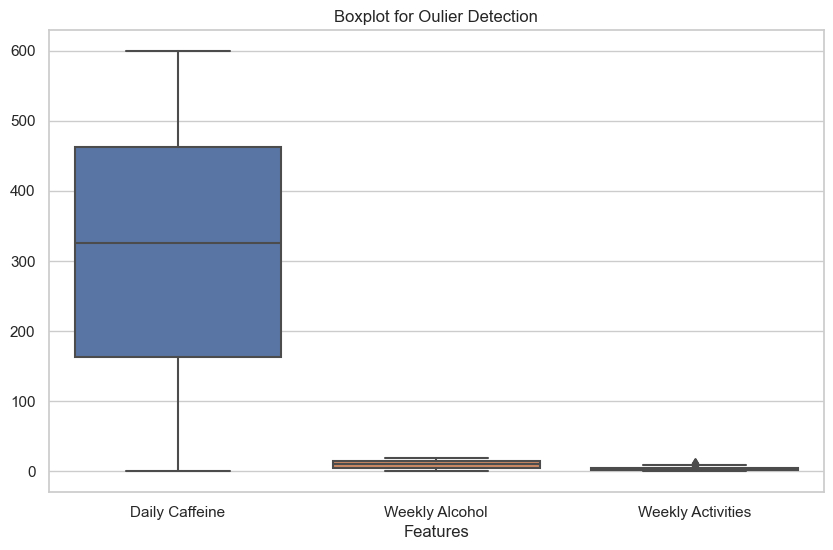

In [368]:
#create a boxplot for Caffeine intake, Alcohol and Pyhsical Activity - lets plot them side by side
plt.figure(figsize=(10,6)) #set fig size
sns.boxplot(data = df_ds[['Daily Caffeine','Weekly Alcohol','Weekly Activities']])

#title and labels to our Visualization
plt.title('Boxplot for Oulier Detection')
plt.xlabel('Features')

plt.show()

#This gives a poor boxplot, we cannot see any of the data on 'Weekly Alcohol','Weekly Activities' as it's numbers are scaled to the Caffeine intake which has a much bigger range

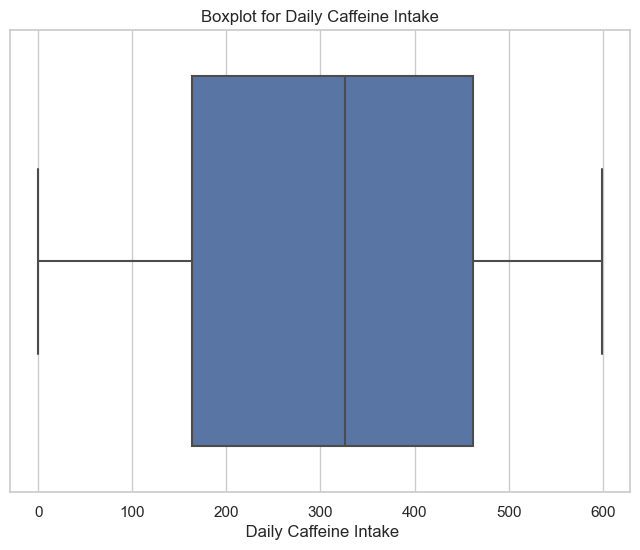

In [369]:
#Let's plot them separately

#Daily Caffeine boxplot

plt.figure(figsize=(8,6)) #set fig size
sns.boxplot(x=df_ds['Daily Caffeine'])

#add title and labels
plt.title('Boxplot for Daily Caffeine Intake')
plt.xlabel(' Daily Caffeine Intake')

#show the plot
plt.show()

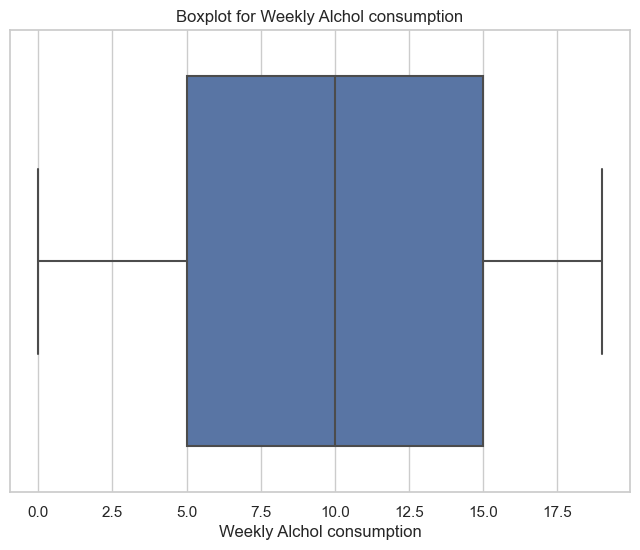

In [370]:
#Weekly Alchol consumption

plt.figure(figsize=(8,6)) #set fig size
sns.boxplot(x=df_ds['Weekly Alcohol'])

#add title and labels
plt.title('Boxplot for Weekly Alchol consumption')
plt.xlabel('Weekly Alchol consumption')

#show the plot
plt.show()

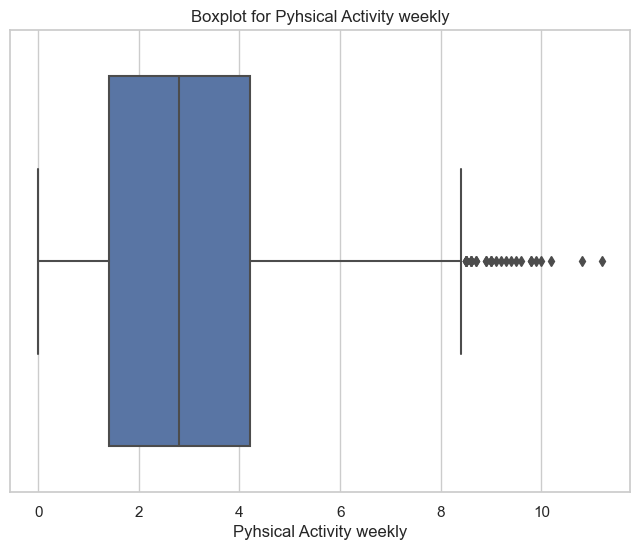

In [371]:
#Pyhsical Activity weekly

plt.figure(figsize=(8,6)) #set fig size
sns.boxplot(x=df_ds['Weekly Activities'])

#add title and labels
plt.title('Boxplot for Pyhsical Activity weekly')
plt.xlabel('Pyhsical Activity weekly')

#show the plot
plt.show()

#We can see in this boxlpot that there is some outliers in the Pyhsical Activity weekly visualization

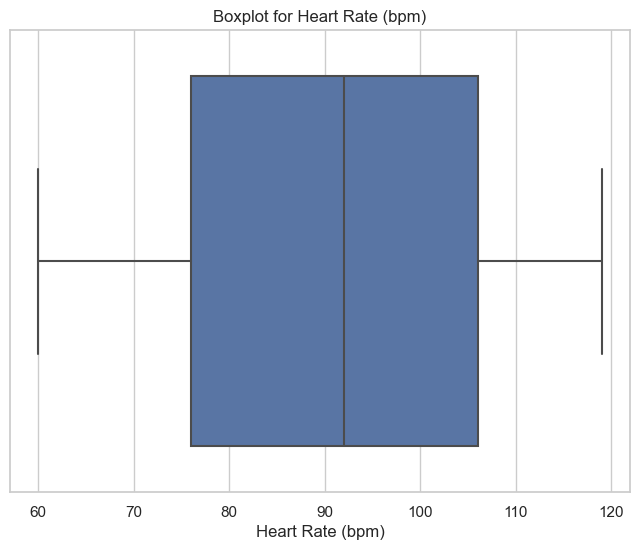

In [372]:
#Let's check our Heart Rate (bpm) for outliers
#Pyhsical Activity weekly

plt.figure(figsize=(8,6)) #set fig size
sns.boxplot(x=df_ds['Heart Rate (bpm)'])

#add title and labels
plt.title('Boxplot for Heart Rate (bpm)')
plt.xlabel('Heart Rate (bpm)')

#show the plot
plt.show()

In [373]:
print(df_ds.shape)

(11000, 32)


In [374]:
#Using the QR -> InterQuartile Range method to deal with outlier - using a function on the columns that may have outliers
columns_ds = ['Weekly Activities','Daily Caffeine','Weekly Alcohol','Heart Rate (bpm)','Breathing Rate (breaths/min)']

def removingOutliers(col):
    """ Return the low and high cutoffs for outlier detection using IQR"""
    q1,q3 = col.quantile([0.25,0.75])
    IQR = q3-q1
    lowerRange = q1 -(1.5 * IQR)
    upperRange = q3 +(1.5 * IQR)
    return lowerRange, upperRange

In [375]:
#you can use this code if you have a small dataset and do not want to remove any outliers
#this replaces any outliers with the upper and lower threshold 

for col in columns_ds:
    low,high = removingOutliers(df_ds[col])
    df_ds[col] = np.where(df_ds[col] > high,high,df_ds[col])
    df_ds[col] = np.where(df_ds[col] < low,low,df_ds[col])

In [376]:
#This for loops iterates through out columns in the list and REMOVES any outliers in our dataset
#I can remove them as I have a huge dataset and this will not affect our results
for col in columns_ds:
    low, high = removingOutliers(df_ds[col])
    df_ds = df_ds[(df_ds[col] >= low) & (df_ds[col] <= high)]

In [377]:
df_ds.head()

,Age,Sleep Hours,Weekly Activities,Daily Caffeine,Weekly Alcohol,Smoking,Family History of Anxiety,Stress Level (1-10),Heart Rate (bpm),Breathing Rate (breaths/min),...,Occupation_Doctor,Occupation_Engineer,Occupation_Freelancer,Occupation_Lawyer,Occupation_Musician,Occupation_Nurse,Occupation_Other,Occupation_Scientist,Occupation_Student,Occupation_Teacher
0,58,6.2,1.3,192.0,16.0,0,1,1,117.0,21.0,...,0,0,0,0,0,1,0,0,0,0
1,39,8.6,3.8,367.0,15.0,0,0,10,113.0,14.0,...,0,1,0,0,0,0,0,0,0,0
2,42,6.6,0.5,132.0,1.0,0,0,10,79.0,20.0,...,1,0,0,0,0,0,0,0,0,0
3,43,7.0,1.6,361.0,15.0,0,0,4,69.0,25.0,...,0,0,0,0,0,0,0,0,0,0
4,55,7.6,2.8,531.0,0.0,0,0,3,65.0,12.0,...,0,0,0,0,0,0,0,0,0,0


In [378]:
df_ds.shape #30 outliers were removed from the dataset

(11000, 32)

In [379]:
#lets split our data before Visualizing it
from sklearn.model_selection import train_test_split

cols_to_drop = ['Gender_Other','Anxiety Level (1-10)'] #dropping Gender_Other for Multicollinearity

X = df_ds.drop(cols_to_drop, axis=1)

y = df_ds['Anxiety Level (1-10)']

X_train, X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [380]:
X.columns

Index(['Age', 'Sleep Hours', 'Weekly Activities', 'Daily Caffeine',
       'Weekly Alcohol', 'Smoking', 'Family History of Anxiety',
       'Stress Level (1-10)', 'Heart Rate (bpm)',
       'Breathing Rate (breaths/min)', 'Sweating Level (1-5)', 'Dizziness',
       'Medication', 'Therapy Sessions (per month)', 'Recent Major Life Event',
       'Diet Quality (1-10)', 'Gender_Female', 'Gender_Male',
       'Occupation_Athlete', 'Occupation_Chef', 'Occupation_Doctor',
       'Occupation_Engineer', 'Occupation_Freelancer', 'Occupation_Lawyer',
       'Occupation_Musician', 'Occupation_Nurse', 'Occupation_Other',
       'Occupation_Scientist', 'Occupation_Student', 'Occupation_Teacher'],
      dtype='object')

In [381]:
y

0        3.0
1        4.0
2        6.0
3        2.0
4        4.0
        ... 
10995    2.0
10996    4.0
10997    6.0
10998    3.0
10999    3.0
Name: Anxiety Level (1-10), Length: 11000, dtype: float64

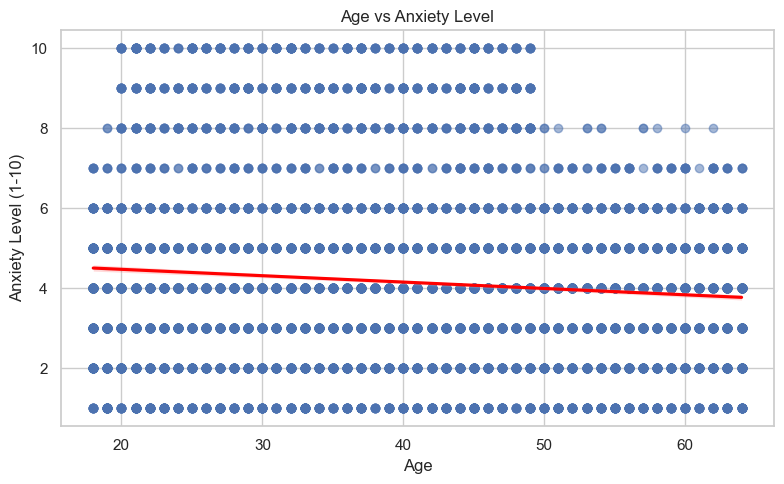

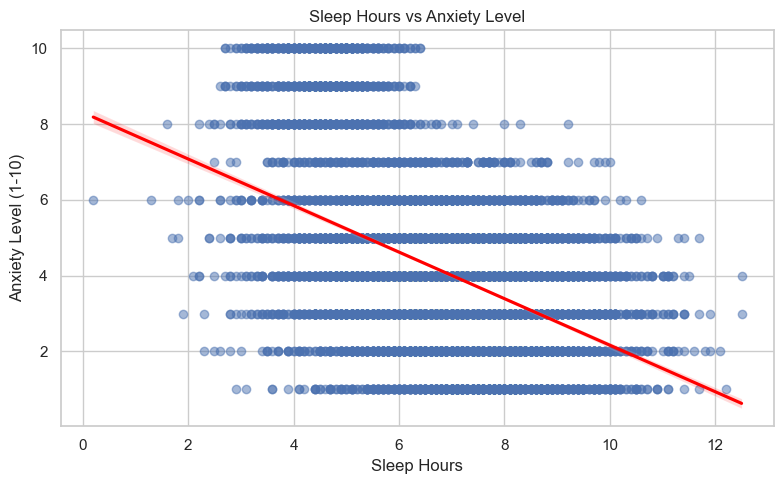

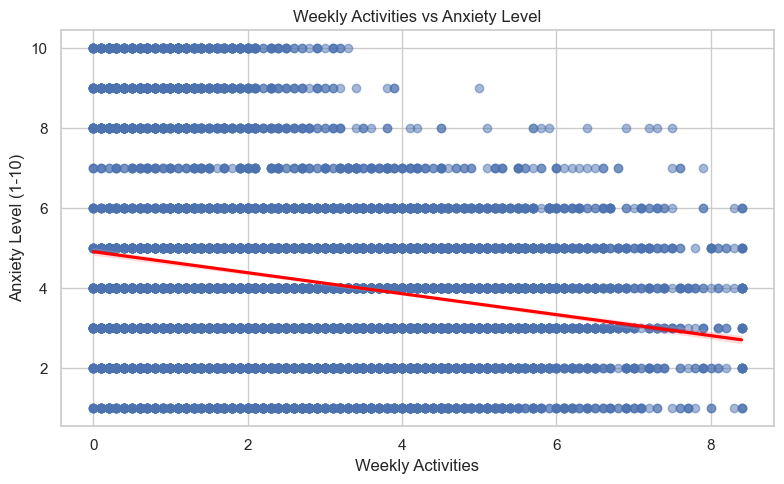

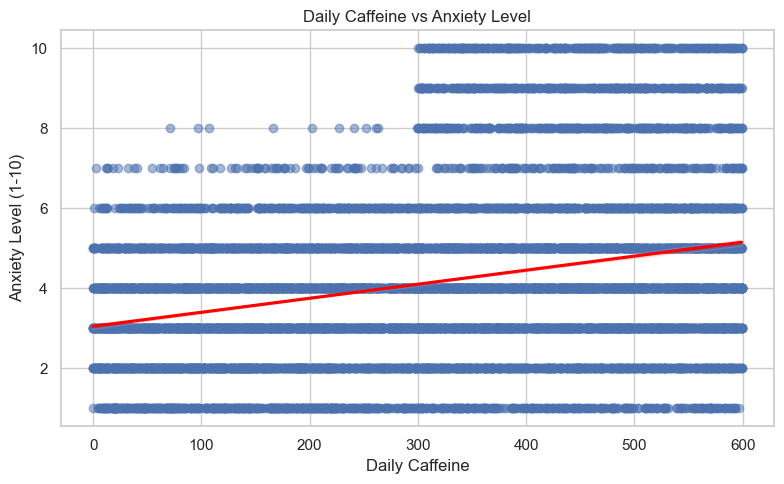

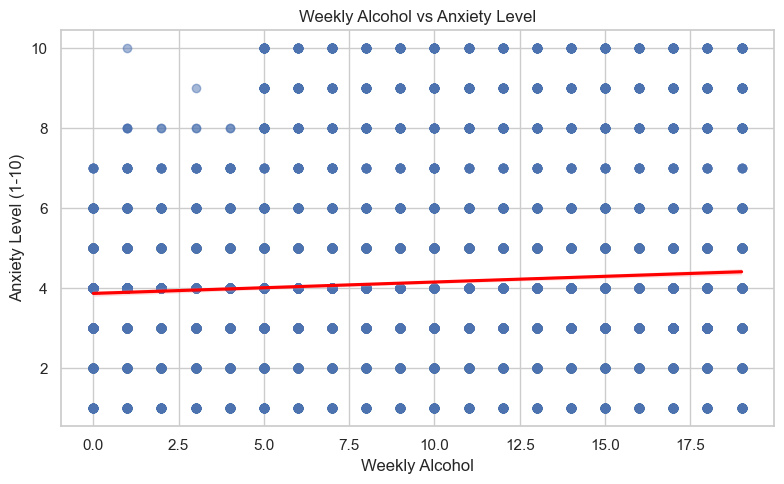

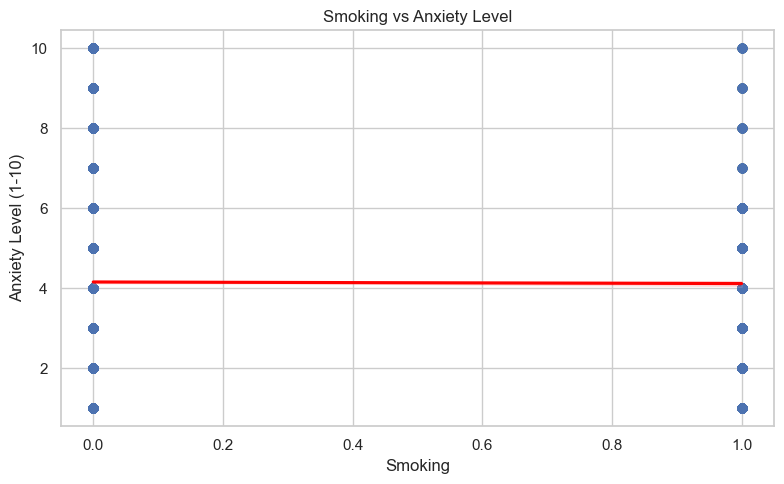

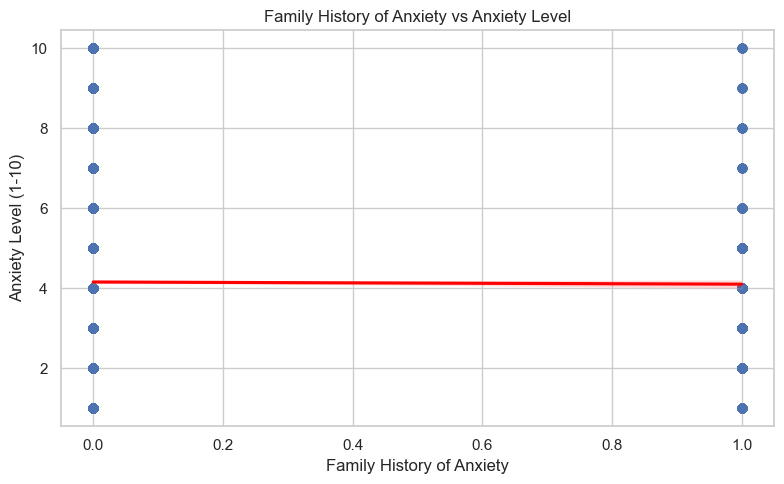

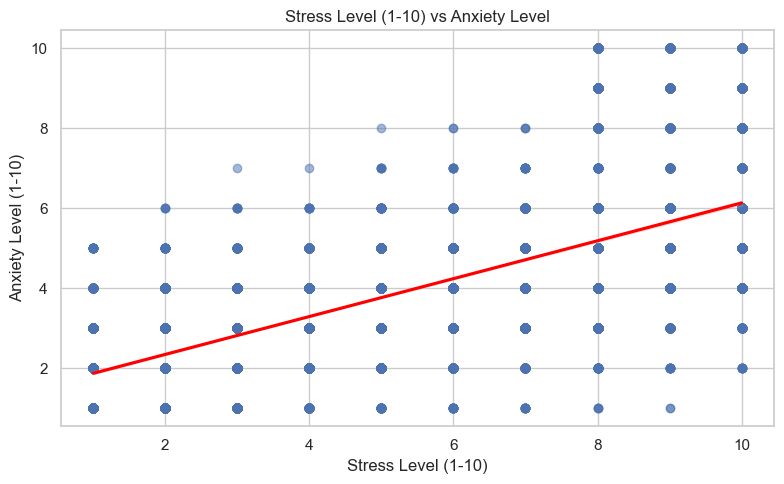

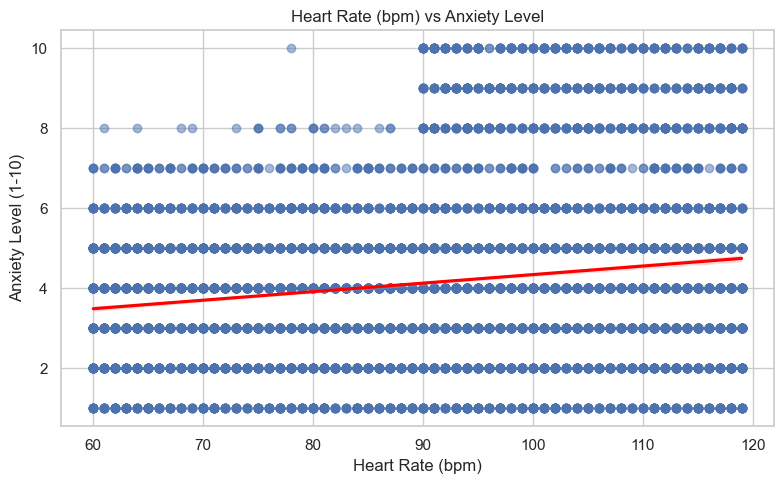

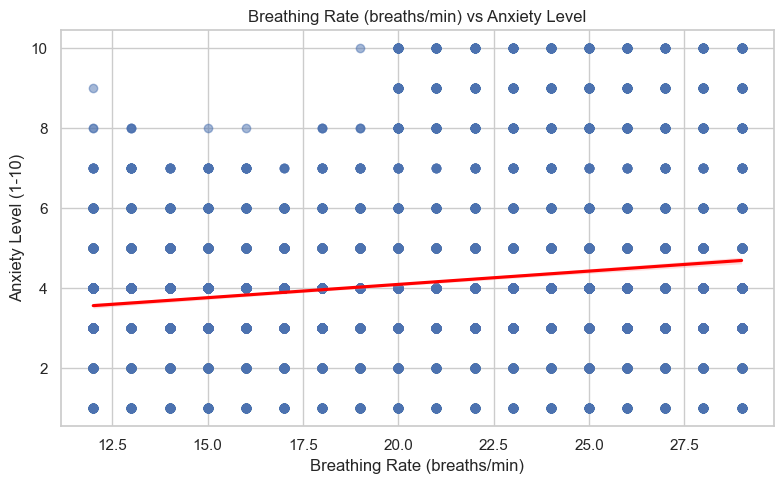

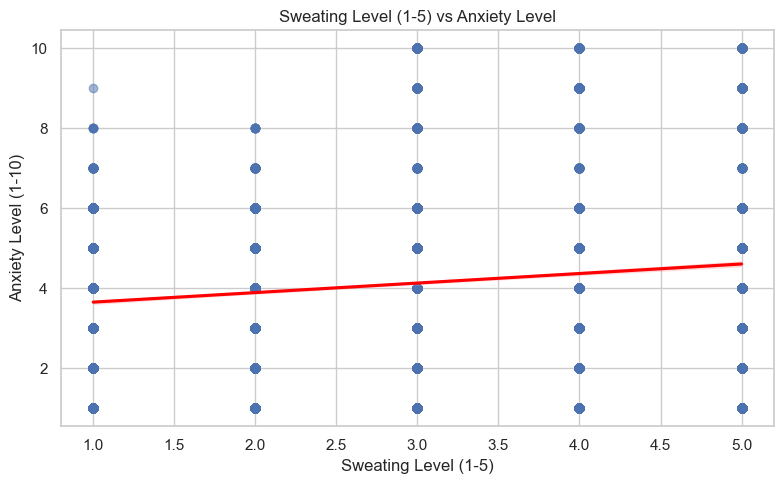

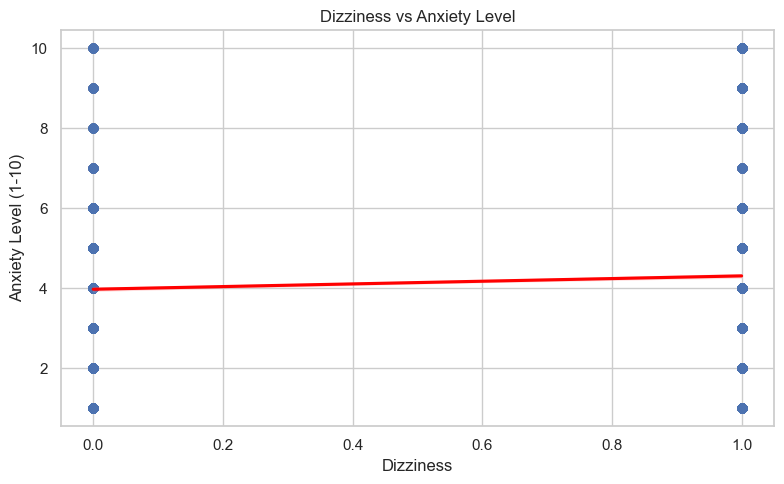

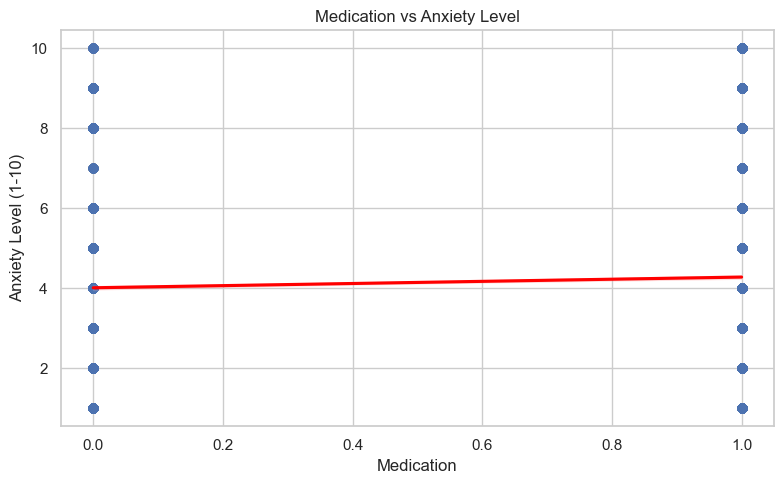

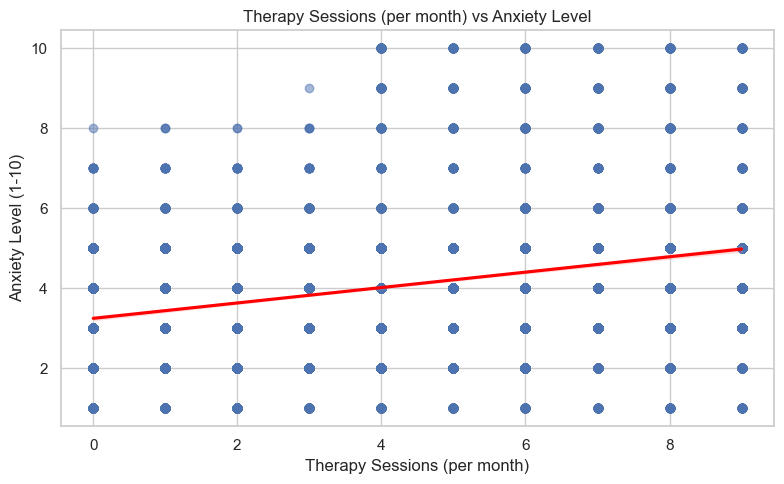

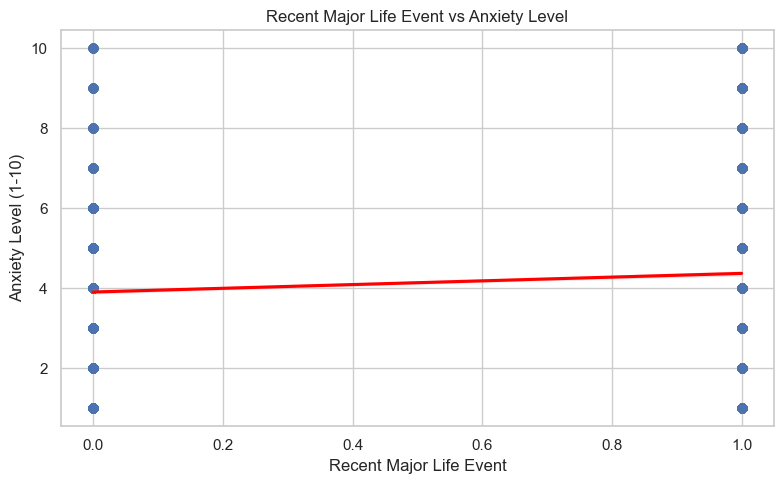

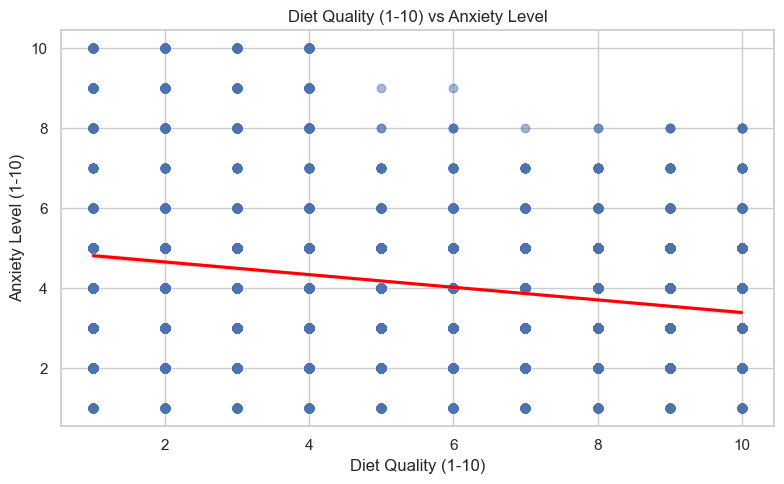

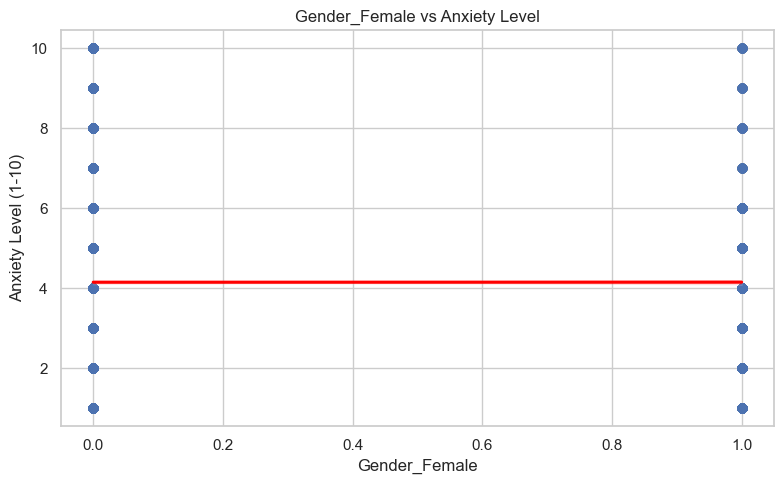

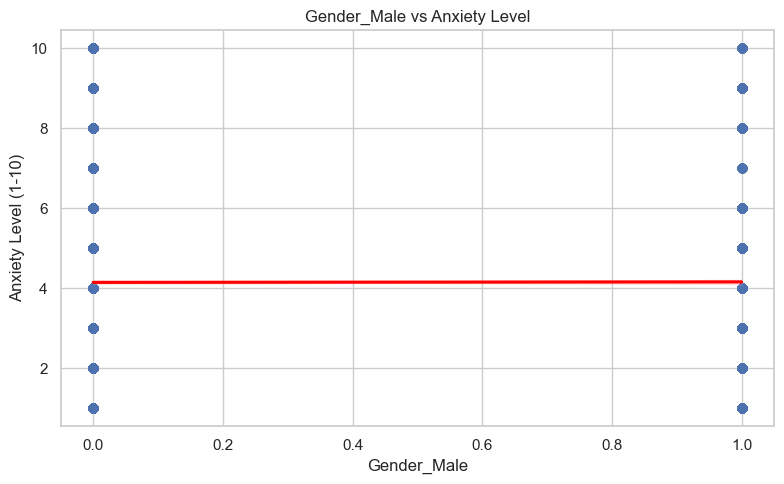

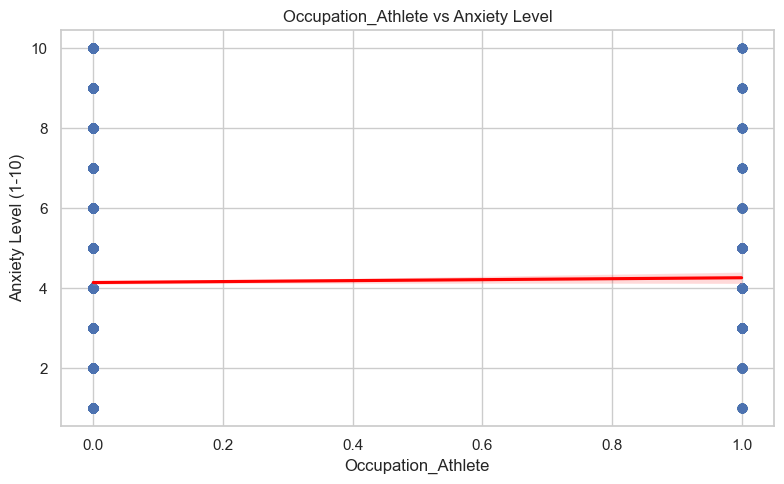

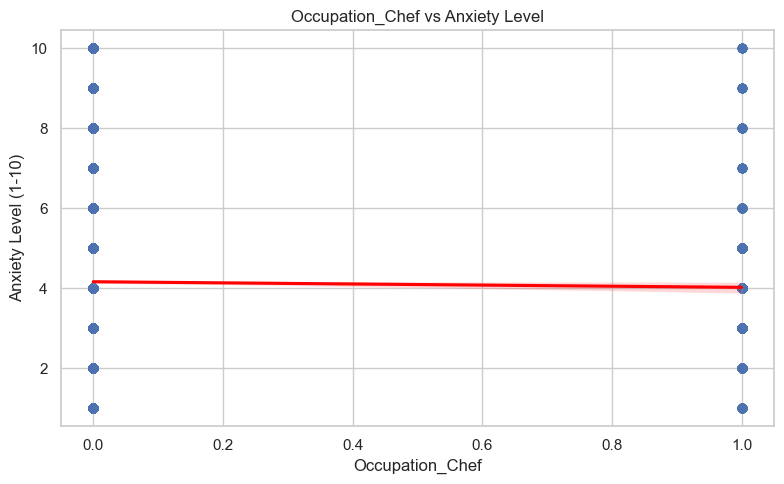

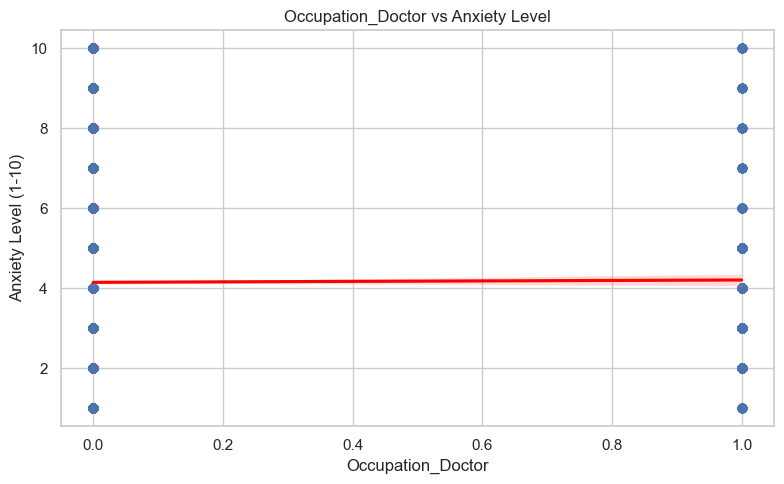

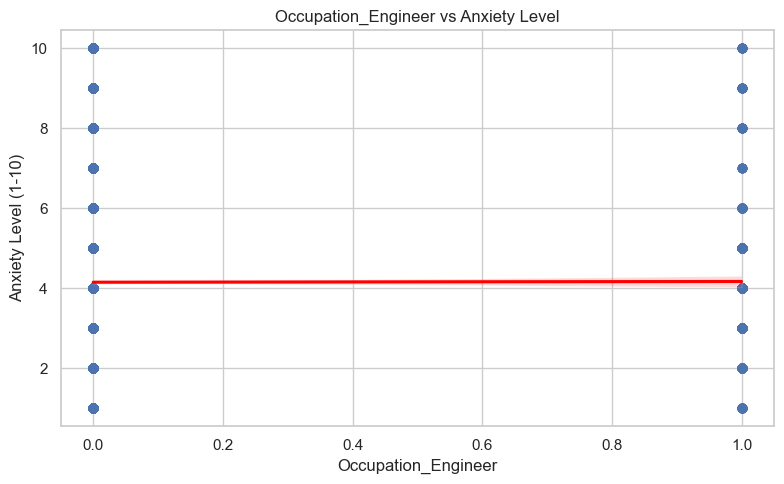

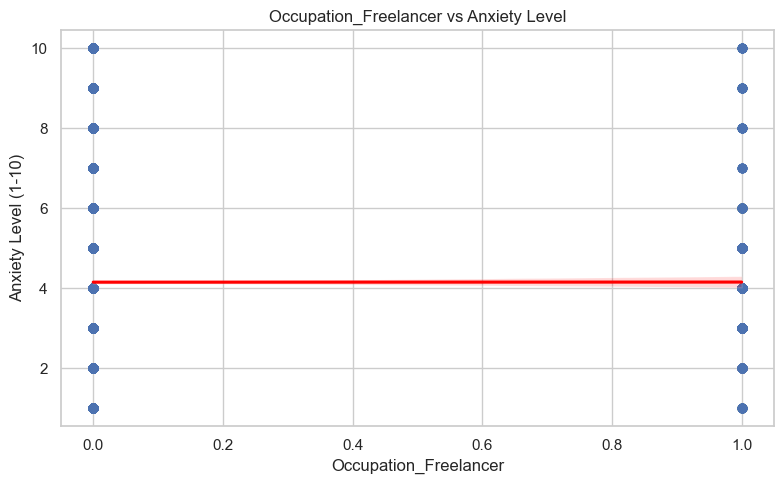

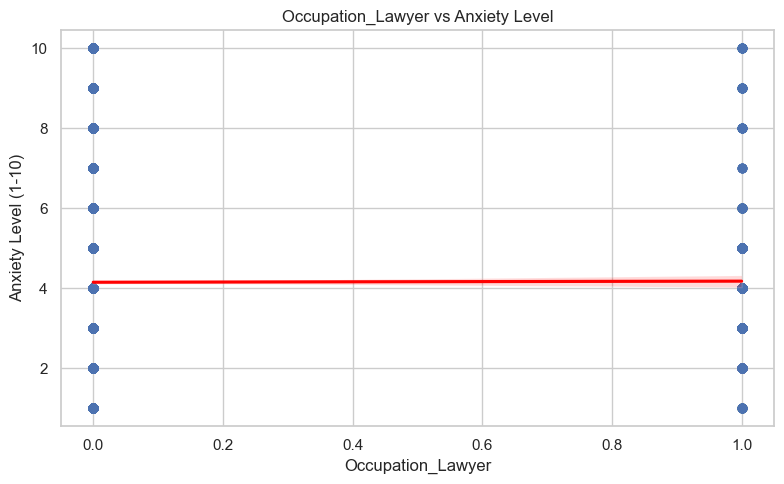

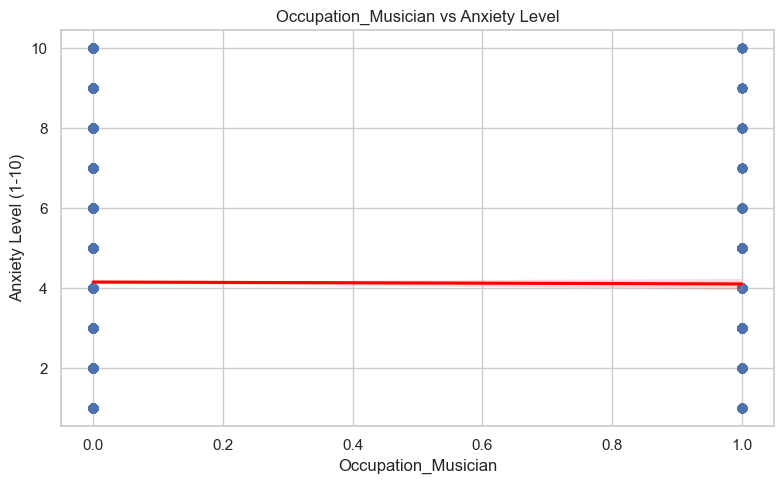

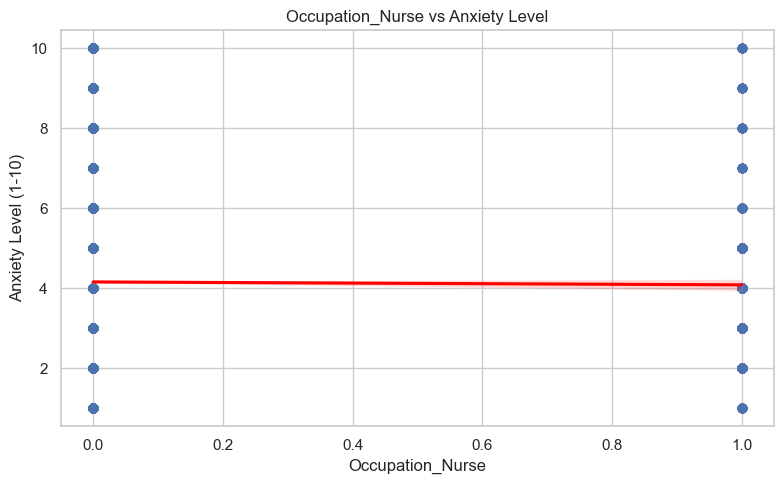

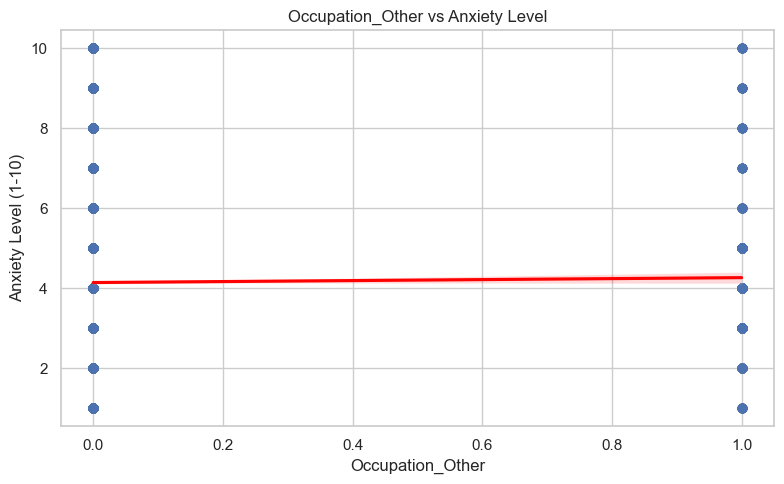

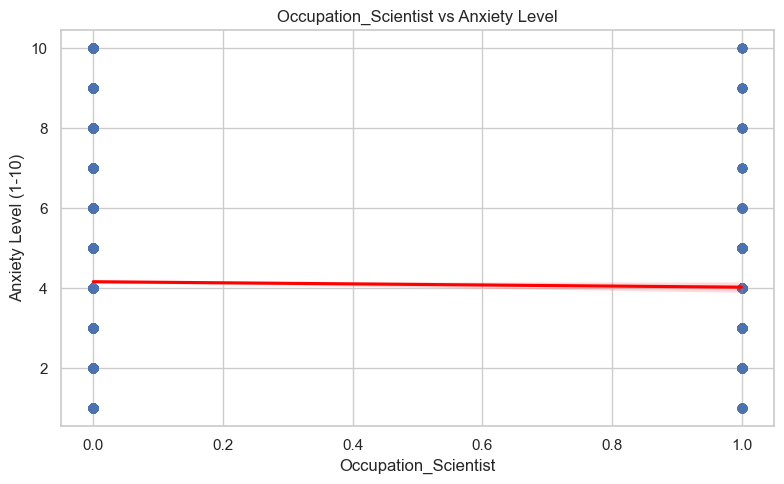

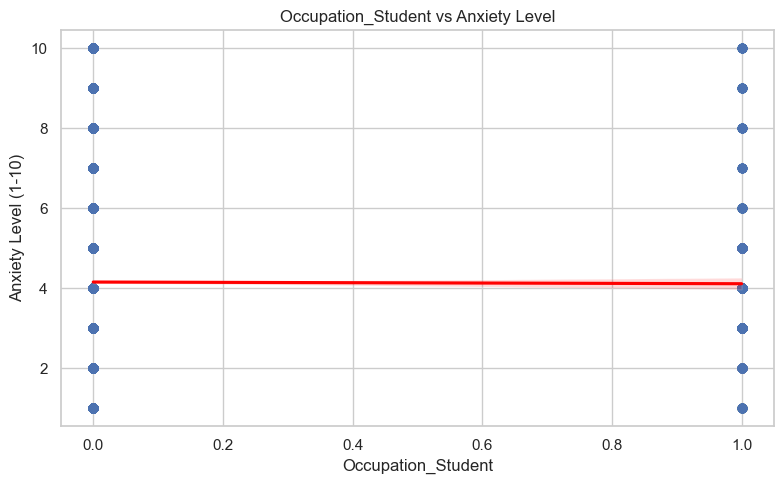

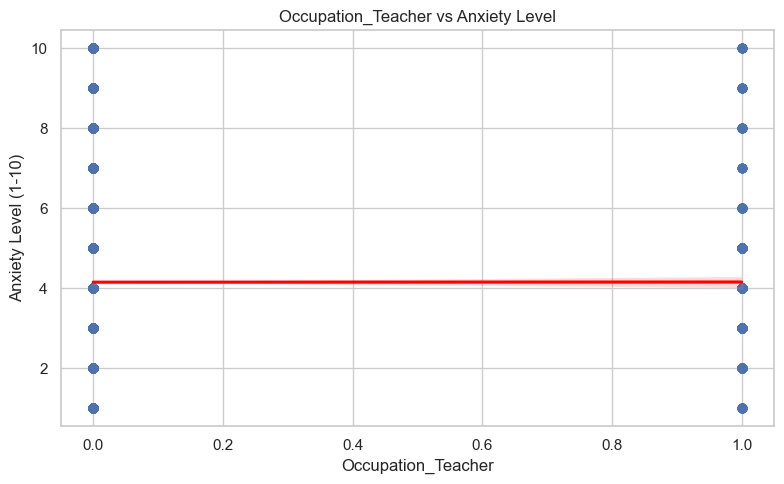

In [382]:
#In these graphs I am looking for possitive correlation between the independent variables and our target varaible to see if we can reduce the 
#size of our independent variables we are inputting in to our model

sns.set(style='whitegrid')

#loop through our dataset columns
for col in X.columns:
    plt.figure(figsize=(8,5))
    sns.regplot(
        x=col,
        y='Anxiety Level (1-10)',
        data = df_ds,
        scatter_kws={'alpha':0.5},
        line_kws={'color':'red'}
    )
    
    plt.title(f'{col} vs Anxiety Level')
    plt.xlabel(col)
    plt.ylabel('Anxiety Level (1-10)')
    plt.tight_layout()
    plt.show()

In [383]:
#UPDATE: I am getting seriously high coffeficents for 'Gender Female', 'Gender_male' and 'Gender_Other'
# I believe there is Multicollinearity between these indepent variables
#X_train = X_train.drop('Gender_Other',axis=1) # I was getting terrible cofficent values for Gender values after one-hot encoding

In [384]:
#Lets Scale our data between 0 and 1
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler() #create an instance of the MinMaxScaler class

X_train_scaled = scaler.fit_transform(X_train) #scale our X_train data

X_test_scaled = scaler.fit_transform(X_test) #scale our test data

X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X.columns) #Convert the scaled data back into DataFrame

X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X.columns)#Convert the scaled data back into DataFrame



# Now you we use X_train_scaled_df and X_test_scaled_df for modeling
print("Scaled Training Data:")
print(X_train_scaled_df.head())

Scaled Training Data:
        Age  Sleep Hours  Weekly Activities  Daily Caffeine  Weekly Alcohol  \
0  0.586957     0.479675           0.619048        0.664441        0.210526   
1  0.217391     0.268293           0.023810        0.707846        0.947368   
2  0.304348     0.390244           0.083333        0.524207        0.947368   
3  0.108696     0.585366           0.059524        0.689482        0.000000   
4  0.500000     0.382114           0.547619        0.804674        0.473684   

   Smoking  Family History of Anxiety  Stress Level (1-10)  Heart Rate (bpm)  \
0      0.0                        0.0             0.000000          0.118644   
1      1.0                        1.0             0.777778          0.525424   
2      0.0                        0.0             1.000000          0.830508   
3      0.0                        0.0             0.888889          0.033898   
4      0.0                        0.0             0.777778          0.796610   

   Breathing Rate (bre

In [385]:
#lets build our model, I can see some neagtive correlations but I do not want to remove them just yet
#I am going to use Lasso Regulartization to help with model selection and also run Linear rgression OLS

from sklearn.linear_model import LinearRegression,Lasso
from sklearn.metrics import mean_squared_error

linreg_model = LinearRegression() #create an instance of the class Linear regression

lasso_model = Lasso(alpha=1.0) #create an instance of the class Lasso regression

#fit our data using our Linear Regression model
linreg_model.fit(X_train_scaled_df,y_train)
lr_preds = linreg_model.predict(X_test_scaled_df)

#Fit our data using out Lasso model
lasso_model.fit(X_train,y_train)
lasso_preds = lasso_model.predict(X_test)

In [386]:
print("Linear Regression Coefficients:")
for name, coef in zip(X.columns, linreg_model.coef_): #iterating through the columns and there coefficents in the model
    print(f"{name}: {coef:.4f}")

print("\nLasso Regression Coefficients:")
for name, coef in zip(X.columns, lasso_model.coef_):
    print(f"{name}: {coef:.4f}")

print(f"\nLinear MSE: {mean_squared_error(y_test, lr_preds):.4f}") #using the mean_sqaured_error metric to seeh how well our model performed on the data
print(f"Lasso MSE: {mean_squared_error(y_test, lasso_preds):.4f}")

Linear Regression Coefficients:
Age: -0.2379
Sleep Hours: -4.8927
Weekly Activities: -0.8051
Daily Caffeine: 1.2759
Weekly Alcohol: 0.1832
Smoking: -0.0330
Family History of Anxiety: -0.0504
Stress Level (1-10): 3.5876
Heart Rate (bpm): 0.4317
Breathing Rate (breaths/min): 0.3294
Sweating Level (1-5): 0.2601
Dizziness: 0.1311
Medication: 0.1550
Therapy Sessions (per month): 1.1580
Recent Major Life Event: 0.1519
Diet Quality (1-10): -0.4794
Gender_Female: 0.0056
Gender_Male: 0.0402
Occupation_Athlete: -0.0772
Occupation_Chef: -0.1699
Occupation_Doctor: 0.0218
Occupation_Engineer: -0.0530
Occupation_Freelancer: -0.0939
Occupation_Lawyer: -0.0587
Occupation_Musician: -0.1078
Occupation_Nurse: -0.0205
Occupation_Other: -0.0490
Occupation_Scientist: -0.1805
Occupation_Student: -0.1495
Occupation_Teacher: -0.0875

Lasso Regression Coefficients:
Age: -0.0041
Sleep Hours: -0.0855
Weekly Activities: -0.0000
Daily Caffeine: 0.0028
Weekly Alcohol: 0.0000
Smoking: -0.0000
Family History of Anxiet

- We can see from the results that the Linear Reegression model performed better
- I believe the Lasso shrunk useful coefficient to much and hurt the performance
- I thought I would have high multicollinearity and Lasso could help with that but it brought all the Gender columns to 0

In [387]:
#Lets just check R2 Score (Coefficent of determination)
#R2 expalins how well our data fits our model and we can see that Linear Regression over Lasso regularization performed much better

from sklearn.metrics import r2_score
r2 = r2_score(y_test, lr_preds)
print(f'R2 Score: {r2:.4f}')

R2 Score: 0.6464


In [388]:
#Using Lasso on scaled data has not worked at all so I just ran our normal dataset not scaled
r2 = r2_score(y_test, lasso_preds) 
print(f'R2 Score: {r2:.4f}')

R2 Score: 0.5366


- UPDATE: I am getting seriously high coffeficents for 'Gender Female', 'Gender_male' and 'Gender_Other'
- I believe there is Multicollinearity between these indepent variables
- I will drop Other_Gender and run the model again

In [337]:
# Linear regression coffefficents

# Gender_Female: 1237688097628.7449
# Gender_Male: 1237688097628.7898
# Gender_Other: 1237688097628.7517

#These were the coeffeicents before I removed the 'Gender_Other' Column

In [390]:
df_ds.to_csv('NoOutliers_Social_Anxiety.csv',index=False)

In [393]:
mse = mean_squared_error(y_test, lr_preds)
print('MSE score',mse)

MSE score 1.6234444793726148
